In [2]:
# Install necessary libraries
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [4]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-4-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [5]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [6]:
# Define the hyperparameter search space for Lasso Regression
lasso_param_grid = {
    'alpha': Real(0.01, 100.0, prior='log-uniform')  # Regularization strength (log-uniform distribution)
}

# Initialize Lasso Regression model
lasso_model = Lasso(random_state=42)

# Initialize BayesSearchCV
lasso_bayes_search = BayesSearchCV(
    lasso_model,
    lasso_param_grid,
    n_iter=20,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric (negative MSE)
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
lasso_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_lasso_model = lasso_bayes_search.best_estimator_
lasso_y_pred = best_lasso_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for Lasso Regression (BayesSearchCV):")
print(lasso_bayes_search.best_params_)

/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [2.1460637226234307]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [6.978714522691171]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.15157697612603846]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.07933520403170938]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.010612484579009207]
  wa

Best Hyperparameters for Lasso Regression (BayesSearchCV):
OrderedDict([('alpha', 100.0)])


In [7]:
# Evaluate the model
lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_mse = mean_squared_error(y_test, lasso_y_pred)
lasso_r2 = r2_score(y_test, lasso_y_pred)

print("Lasso Regression Model Performance:")
print("Mean Absolute Error:", lasso_mae)
print("Mean Squared Error:", lasso_mse)
print("R-squared:", lasso_r2)

Lasso Regression Model Performance:
Mean Absolute Error: 127629.20290026854
Mean Squared Error: 42950613293.35106
R-squared: 0.6828429626675483


In [8]:
# Cross-validation for Lasso Regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_lasso = cross_validate(best_lasso_model, X_train, y_train, cv=kf, scoring=scoring)
print("Lasso Regression Cross-Validation Results:")
print("Mean MAE:", -cv_results_lasso['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_lasso['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_lasso['test_r2'].mean())

Lasso Regression Cross-Validation Results:
Mean MAE: 128754.0194098778
Mean MSE: 45139485597.044876
Mean R2: 0.6835665067969376


In [9]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for Lasso Regression
lasso_mape = mean_absolute_percentage_error(y_test, lasso_y_pred)
print(f"Lasso Regression MAPE: {lasso_mape:.2f}%")

Lasso Regression MAPE: 57.85%


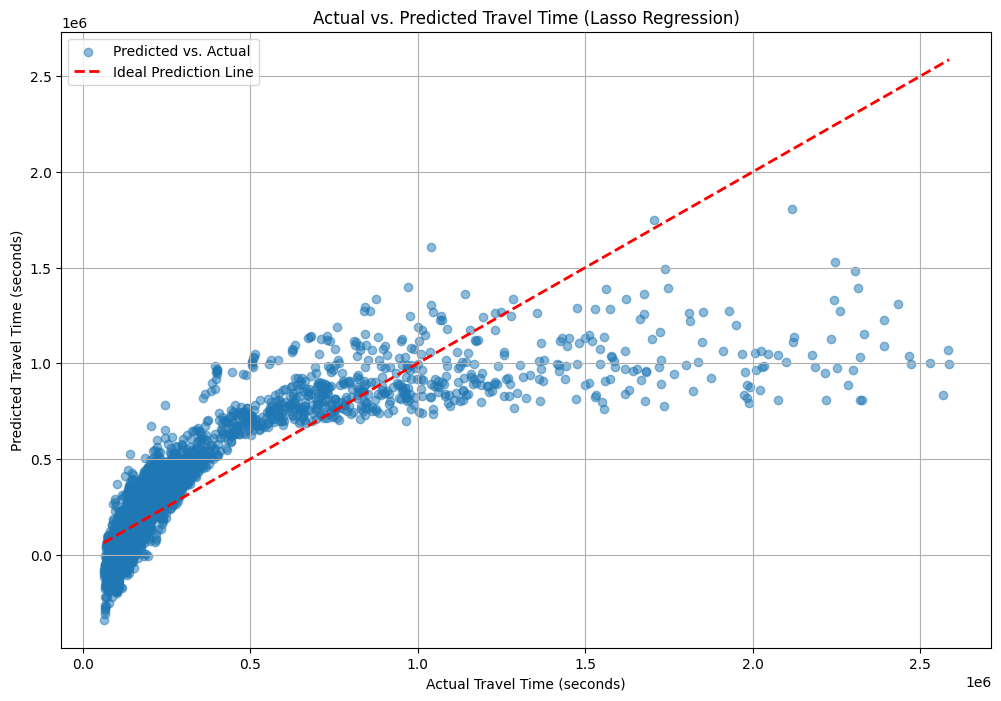

In [13]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, lasso_y_pred, alpha=0.5, label='Predicted vs. Actual')  # Add label for scatter plot
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal Prediction Line')  # Add label for red dashed line
plt.title('Actual vs. Predicted Travel Time (Lasso Regression)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.legend()  # Display legend
plt.grid(True)
plt.show()